In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
import shap
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

from datetime import datetime
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold


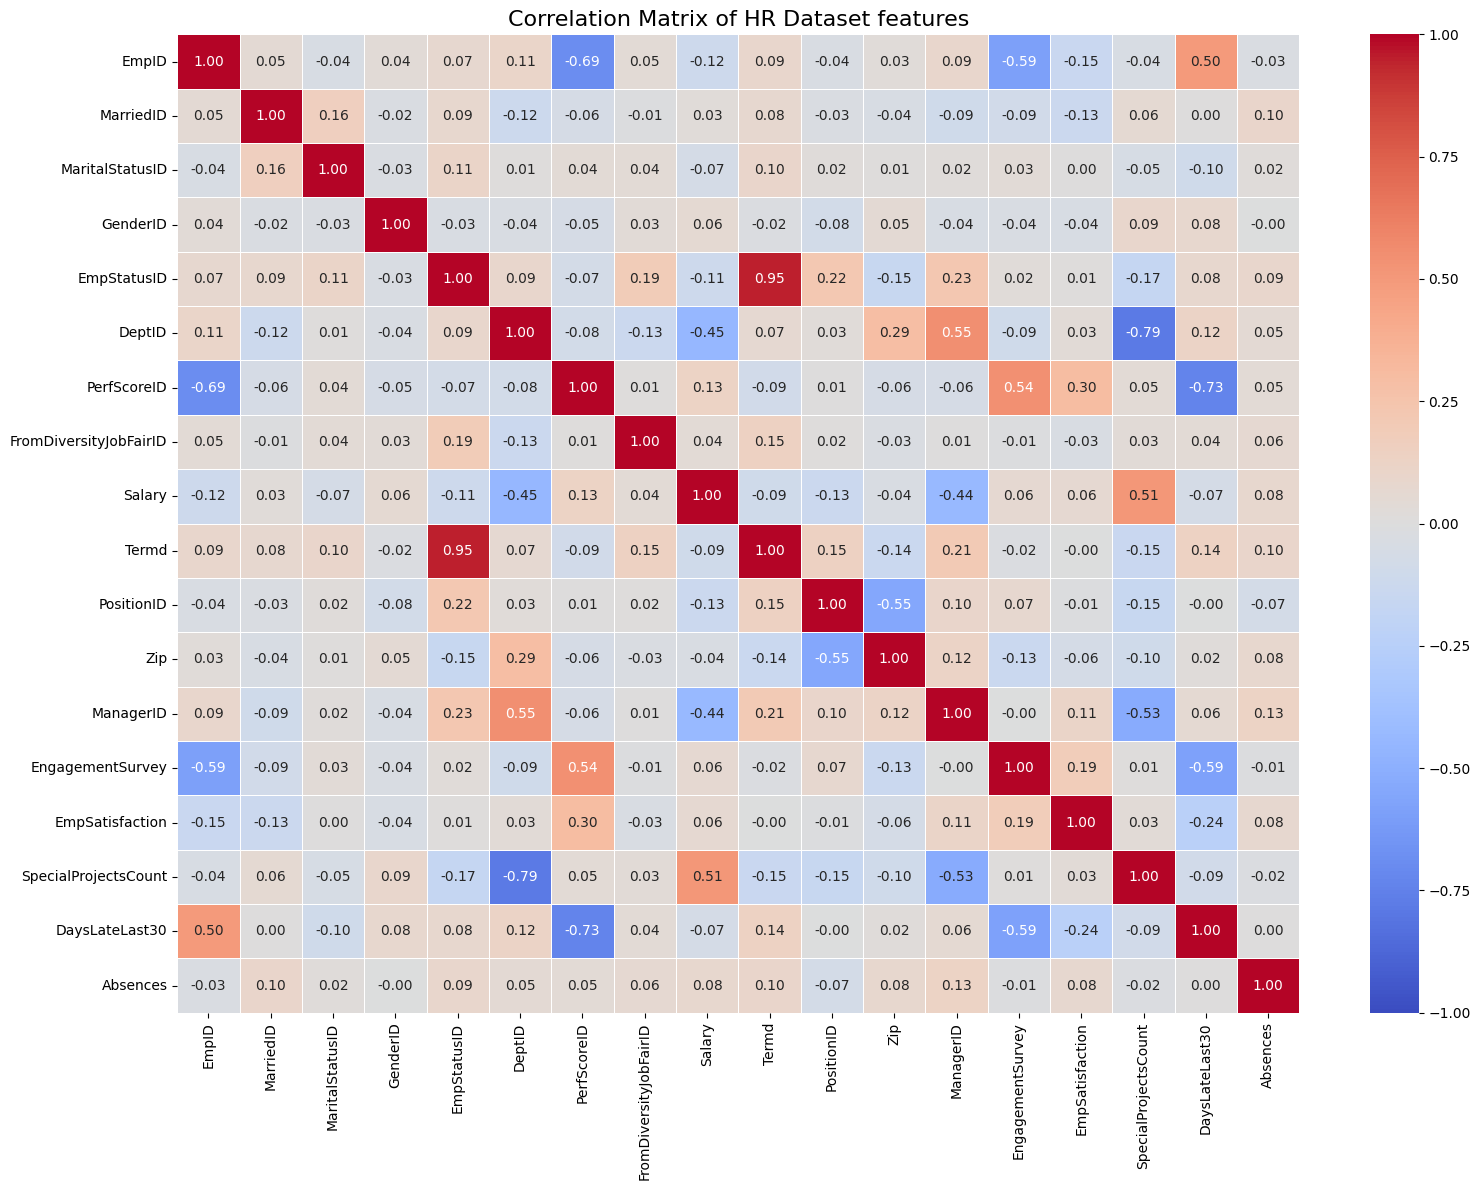

In [123]:
df = pd.read_csv("data/HRDataset_v14.csv")

# Make the correlation matrix
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])
# Calculate the correlation matrix
# By default, this uses Pearson correlation
correlation_matrix = numeric_df.corr()
# Set up the matplotlib figure
plt.figure(figsize=(16, 12)) # Make it large enough to read easily
# 5. Draw the heatmap using seaborn
sns.heatmap(
    correlation_matrix, 
    annot=True,         # Show the correlation numbers in the boxes
    fmt=".2f",          # Round numbers to 2 decimal places
    cmap="coolwarm",    # Color map: Red = High positive correlation, Blue = High negative
    vmin=-1, vmax=1,    # Set the scale from -1 to 1
    linewidths=0.5      # Add slight spacing between boxes
)
# Add title and display the plot
plt.title("Correlation Matrix of HR Dataset features", fontsize=16)
plt.tight_layout()
plt.show()


In [124]:
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'])

# Define extraction date (for active employees) - best to use 2019-12-31 to match the dataset's era
date_extraction = pd.to_datetime('2019-12-31')

# 3. Calcul de l'ancienneté (Tenure) en ANNÉES
df['Seniority'] = np.where(df['Termd'] == 1,
                                  (df['DateofTermination'] - df['DateofHire']).dt.days / 365.25,
                                  (date_extraction - df['DateofHire']).dt.days / 365.25)

df['Seniority'] = df['Seniority'].round(2)

# Important : Drop raw dates that leak termination info
df = df.drop(columns=['DateofHire', 'DateofTermination'])

# Vérification du résultat
print(df[['Termd', 'Seniority']].head())


   Termd  Seniority
0      0       8.49
1      1       1.22
2      1       1.22
3      0      11.98
4      1       5.16


Variables à garder : Les Vrais Prédicteurs (Features)
Ce sont les variables saines sur lesquelles les RH pourront analyser les probabilités de démission et suggérer des actions concrètes.

- Salary : Très pertinent financièrement.
- Position & Department : Certains rôles ou départements sont-ils sujets à un turnover plus élevé ?
- ManagerName : Un levier fondamental (on dit souvent qu'un employé quitte un manager, pas une entreprise).
- PerformanceScore : Les employés sous-performants partent-ils plus souvent, ou inversement les hauts potentiels s'envolent-ils ailleurs ?
- EngagementSurvey & EmpSatisfaction : Les scores d'engagement ou de satisfaction sont de loin les signaux les plus forts et les plus actionnables pour les RH.
- SpecialProjectsCount : Bon indicateur d'implication intellectuelle et financière pour la compagnie.
- Absences & DaysLateLast30 : Ce sont d'excellents repères comportementaux, souvent précurseurs d'un désengagement (Quiet Quitting).
- RecruitmentSource : Certains canaux (LinkedIn, Referral) fidélisent-il mieux ?

In [125]:
columns_to_keep = [
    'Salary', 
    'Position', 
    'Department', 
    'ManagerName', 
    'PerformanceScore', 
    'EngagementSurvey', 
    'EmpSatisfaction', 
    'SpecialProjectsCount', 
    'Absences', 
    'DaysLateLast30', 
    'RecruitmentSource',
    'Termd', # What we try to predict
    'Seniority',
]
df = df[columns_to_keep]


print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Salary                311 non-null    int64  
 1   Position              311 non-null    object 
 2   Department            311 non-null    object 
 3   ManagerName           311 non-null    object 
 4   PerformanceScore      311 non-null    object 
 5   EngagementSurvey      311 non-null    float64
 6   EmpSatisfaction       311 non-null    int64  
 7   SpecialProjectsCount  311 non-null    int64  
 8   Absences              311 non-null    int64  
 9   DaysLateLast30        311 non-null    int64  
 10  RecruitmentSource     311 non-null    object 
 11  Termd                 311 non-null    int64  
 12  Seniority             311 non-null    float64
dtypes: float64(2), int64(6), object(5)
memory usage: 31.7+ KB
None


In [126]:
# Ordinal Encoding for PerformanceScore
# PerformanceScore has a specific, measurable order. 
# We map it to numbers so the algorithm understands that Exceeds > Fully Meets > Needs Improvement > PIP
performance_mapping = {
    'PIP': 1, 
    'Needs Improvement': 2, 
    'Fully Meets': 3, 
    'Exceeds': 4
}
# Apply the dictionary mapping to the column
df['PerformanceScore'] = df['PerformanceScore'].map(performance_mapping)

# One-Hot Encoding for Nominal Variables
# Position, Department, ManagerName, and RecruitmentSource don't have a mathematical "order".
# A "Data Analyst" isn't strictly "greater than" or "less than" an "IT Support" logically.
# We use One-Hot Encoding to turn these into separate binary (0 or 1) columns.
categorical_cols_to_encode = [
    'Position', 
    'Department', 
    'ManagerName', 
    'RecruitmentSource'
]

# pd.get_dummies converts them. 
# drop_first=True is used to avoid the "dummy variable trap" (perfect multicollinearity)
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# Let's check the result (you'll see your dataset now has a lot more columns, all numeric!)
print(df.head())
print(f"Total columns after encoding: {len(df.columns)}")



   Salary  PerformanceScore  EngagementSurvey  EmpSatisfaction  \
0   62506                 4              4.60                5   
1  104437                 3              4.96                3   
2   64955                 3              3.02                3   
3   64991                 3              4.84                5   
4   50825                 3              5.00                4   

   SpecialProjectsCount  Absences  DaysLateLast30  Termd  Seniority  \
0                     0         1               0      0       8.49   
1                     6        17               0      1       1.22   
2                     0         3               0      1       1.22   
3                     0        15               0      0      11.98   
4                     0         2               0      1       5.16   

   Position_Administrative Assistant  ...  ManagerName_Simon Roup  \
0                              False  ...                   False   
1                              False  

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 73 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Salary                                     311 non-null    int64  
 1   PerformanceScore                           311 non-null    int64  
 2   EngagementSurvey                           311 non-null    float64
 3   EmpSatisfaction                            311 non-null    int64  
 4   SpecialProjectsCount                       311 non-null    int64  
 5   Absences                                   311 non-null    int64  
 6   DaysLateLast30                             311 non-null    int64  
 7   Termd                                      311 non-null    int64  
 8   Seniority                                  311 non-null    float64
 9   Position_Administrative Assistant          311 non-null    bool   
 10  Position_Area Sales Manage

# Creating the models 



## XGBoost

Training dataset size: 248 employees
Testing dataset size: 63 employees

Training XGBoost model...

     XGBOOST MODEL PERFORMANCE
Accuracy:  0.9048  (Overall correctness)
Precision: 1.0000  (When it predicts 'Quit', how often is it right?)
Recall:    0.7143  (How many total 'Quitters' did it identify?)
F1 Score:  0.8333  (Balance of Precision and Recall)
ROC AUC:   0.9501  (Ability to distinguish classes)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        42
           1       1.00      0.71      0.83        21

    accuracy                           0.90        63
   macro avg       0.94      0.86      0.88        63
weighted avg       0.92      0.90      0.90        63



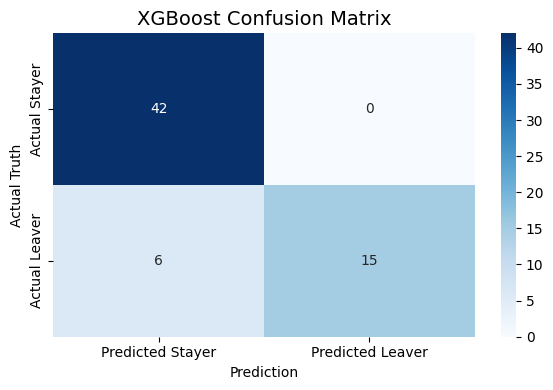

In [128]:
# --- 1. Define Features (X) and Target (y) ---
# Assuming 'df' is your fully cleaned and encoded DataFrame from the previous steps
# The target variable is 'Termd'
X = df.drop('Termd', axis=1)
y = df['Termd']

# --- 2. Train / Test Split ---
# We split the data: 80% for training the model, 20% for testing it on unseen data.
# stratify=y ensures both sets have the same proportion of people who quit vs stayed.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training dataset size: {X_train.shape[0]} employees")
print(f"Testing dataset size: {X_test.shape[0]} employees")

# --- 3. Initialize and Train XGBoost Model ---
# We use standard hyperparameters here, but XGBoost is very tunable
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      # Number of trees
    learning_rate=0.1,     # How much each tree contributes
    max_depth=4,           # Depth of each tree (keep low to prevent overfitting)
    random_state=42,
    eval_metric='logloss'  # Standard evaluation metric for binary classification
)

# Train the model!
print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)

# --- 4. Make Predictions on the Test Set ---
# Predict exact class (0 or 1)
y_pred = xgb_model.predict(X_test)
# Predict probability (percentage risk)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# --- 5. Evaluate Performance ---
print("\n" + "="*40)
print("     XGBOOST MODEL PERFORMANCE")
print("="*40)

# Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}  (Overall correctness)")
print(f"Precision: {precision:.4f}  (When it predicts 'Quit', how often is it right?)")
print(f"Recall:    {recall:.4f}  (How many total 'Quitters' did it identify?)")
print(f"F1 Score:  {f1:.4f}  (Balance of Precision and Recall)")
print(f"ROC AUC:   {roc_auc:.4f}  (Ability to distinguish classes)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- 6. Visualize the Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Stayer', 'Predicted Leaver'],
            yticklabels=['Actual Stayer', 'Actual Leaver'])
plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('Actual Truth')
plt.tight_layout()
plt.show()


In [129]:
# Use a fresh unfitted clone — cross_val_score handles this automatically
# but being explicit avoids any confusion
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_scores = cross_val_score(
    xgb.XGBClassifier(          # fresh instance, same hyperparams
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric='logloss'
    ),
    X, y,                        # ← full dataset, NOT X_train only
    cv=cv,
    scoring='roc_auc'
)

print(f"CV ROC AUC: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"Individual folds: {scores.round(3)}")

CV ROC AUC: 0.933 ± 0.015
Individual folds: [0.888 0.97  0.94  0.814 0.905]


In [130]:
from sklearn.model_selection import cross_val_score
xgb_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='roc_auc')
print(f"CV ROC AUC: {scores.mean():.3f} ± {scores.std():.3f}")

CV ROC AUC: 0.903 ± 0.053


## LightGBM

Training dataset size: 248 employees
Testing dataset size: 63 employees

Training LightGBM model...

     LIGHTGBM MODEL PERFORMANCE
Accuracy:  0.9048  (Overall correctness)
Precision: 0.9412  (When it predicts 'Quit', how often is it right?)
Recall:    0.7619  (How many total 'Quitters' did it identify?)
F1 Score:  0.8421  (Balance of Precision and Recall)
ROC AUC:   0.9388  (Ability to distinguish classes)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.94      0.76      0.84        21

    accuracy                           0.90        63
   macro avg       0.92      0.87      0.89        63
weighted avg       0.91      0.90      0.90        63



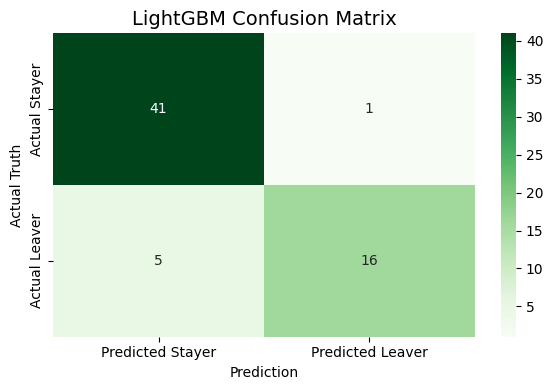

In [131]:
# Define Features (X) and Target (y)
# Assuming 'df' is your fully cleaned and encoded DataFrame from the previous steps
# The target variable is 'Termd'
X = df.drop('Termd', axis=1)
y = df['Termd']

# Train / Test Split
# We split the data: 80% for training the model, 20% for testing it on unseen data.
# stratify=y ensures both sets have the same proportion of people who quit vs stayed.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training dataset size: {X_train.shape[0]} employees")
print(f"Testing dataset size: {X_test.shape[0]} employees")

# Initialize and Train LightGBM Model
# LightGBM uses leaf-wise growth, meaning num_leaves is the main way to control complexity
# instead of max_depth.
lgb_model = lgb.LGBMClassifier(
    n_estimators=100,      # Number of trees
    learning_rate=0.1,     # How much each tree contributes
    num_leaves=15,         # Max number of leaves per tree (keep low to prevent overfitting, < 2^max_depth)
    max_depth=4,           # You can still set max_depth as an additional constraint
    random_state=42,
    verbose=-1             # Suppresses unnecessary LightGBM warnings in output
)

# Train the model!
print("\nTraining LightGBM model...")
lgb_model.fit(X_train, y_train)

# Make Predictions on the Test Set
# Predict exact class (0 or 1)
y_pred = lgb_model.predict(X_test)
# Predict probability (percentage risk)
y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

# Evaluate Performance
print("\n" + "="*40)
print("     LIGHTGBM MODEL PERFORMANCE")
print("="*40)

# Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}  (Overall correctness)")
print(f"Precision: {precision:.4f}  (When it predicts 'Quit', how often is it right?)")
print(f"Recall:    {recall:.4f}  (How many total 'Quitters' did it identify?)")
print(f"F1 Score:  {f1:.4f}  (Balance of Precision and Recall)")
print(f"ROC AUC:   {roc_auc:.4f}  (Ability to distinguish classes)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', # Changed color to Greens for variety
            xticklabels=['Predicted Stayer', 'Predicted Leaver'],
            yticklabels=['Actual Stayer', 'Actual Leaver'])
plt.title('LightGBM Confusion Matrix', fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('Actual Truth')
plt.tight_layout()
plt.show()


In [132]:
# --- Cross-Validation for LightGBM ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_lgbm = cross_val_score(
    lgb.LGBMClassifier(          # fresh instance, same hyperparams as your model
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbose=-1               # silences LightGBM training logs
    ),
    X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"LightGBM CV ROC AUC: {scores_lgbm.mean():.3f} ± {scores_lgbm.std():.3f}")
print(f"Individual folds: {scores_lgbm.round(3)}")

# --- Direct comparison ---
print("\n--- Model Comparison ---")
print(f"XGBoost   CV ROC AUC: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"LightGBM  CV ROC AUC: {scores_lgbm.mean():.3f} ± {scores_lgbm.std():.3f}")

LightGBM CV ROC AUC: 0.930 ± 0.015
Individual folds: [0.916 0.911 0.93  0.938 0.954]

--- Model Comparison ---
XGBoost   CV ROC AUC: 0.903 ± 0.053
LightGBM  CV ROC AUC: 0.930 ± 0.015


## SHAP

  GLOBAL EXPLAINABILITY (Summary Plot)


/Users/henri/Documents/AAA ESILV/A4/S8/Explainability AI/Hackathon-AI/venv/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


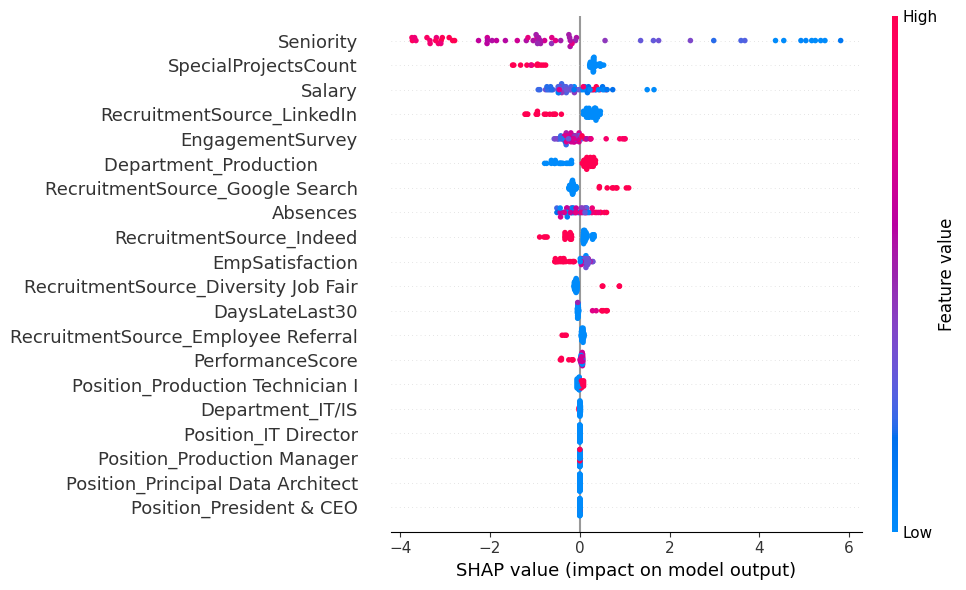


  LOCAL EXPLAINABILITY (Waterfall Plot)


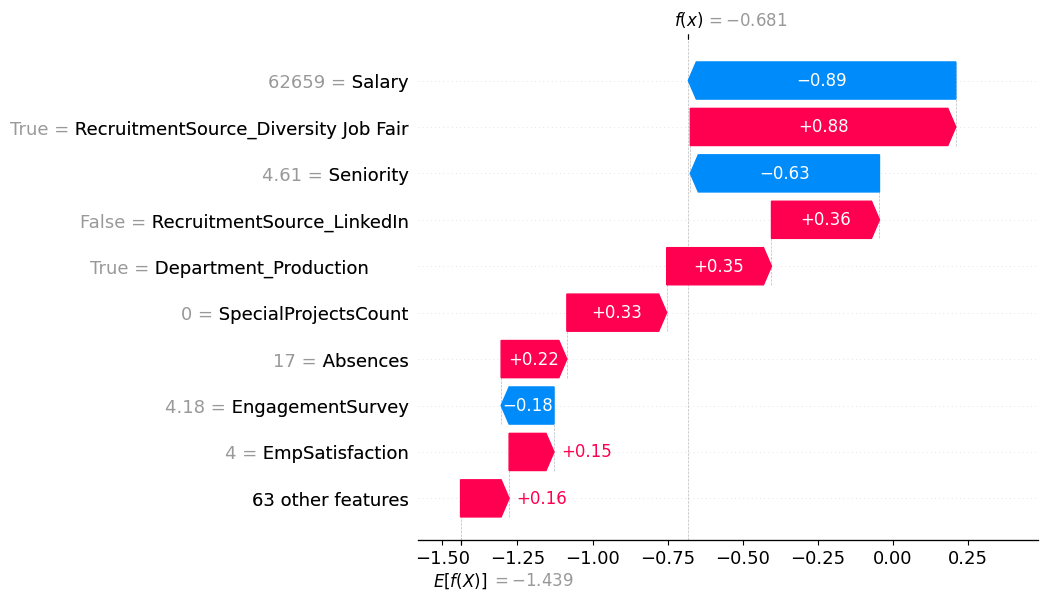

In [133]:
# Initialize JS visualization for SHAP inside Jupyter
shap.initjs()

# --- 1. Create the SHAP Explainer ---
# The TreeExplainer is mathematically optimized for XGBoost/LightGBM/RandomForest
# Note: If you used xgb_model in the previous step, just replace lgb_model with xgb_model here.
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for the Test set
# This might take a few seconds on very large datasets, but for HR data it is instant.
shap_values = explainer.shap_values(X_test)

# --- 2. GLOBAL EXPLAINABILITY (The "Big Picture" for HR) ---
print("=========================================")
print("  GLOBAL EXPLAINABILITY (Summary Plot)")
print("=========================================")
# This plot shows the most important features across the entire dataset.
# The color represents the *value* of the feature (e.g., High Salary vs Low Salary)
# and the position on the X-axis shows if it pushed the risk of leaving UP or DOWN.

plt.figure(figsize=(10, 6))
# For LightGBM binary classification, shap_values is sometimes a list of arrays [class_0, class_1].
# We want the explanation for class 1 (Terminated)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test, plot_size=(10, 6))
else:
    # Depending on the shap/lightgbm version, it might just return one array
    shap.summary_plot(shap_values, X_test, plot_size=(10, 6))


# --- 3. LOCAL EXPLAINABILITY (Explaining a Single Employee's Risk) ---
print("\n=========================================")
print("  LOCAL EXPLAINABILITY (Waterfall Plot)")
print("=========================================")
# Let's explain the prediction for the very first employee in our Test Set (Index 0)
employee_index = 0

# Get the specific SHAP values for this one person
if isinstance(shap_values, list):
    single_person_shap = shap_values[1][employee_index]
    expected_val = explainer.expected_value[1]
else:
    single_person_shap = shap_values[employee_index]
    expected_val = explainer.expected_value
    
# To draw a waterfall plot, SHAP requires an 'Explanation' object in newer versions
explanation_object = shap.Explanation(
    values=single_person_shap, 
    base_values=expected_val, 
    data=X_test.iloc[employee_index].values, 
    feature_names=X_test.columns
)

# Draw the waterfall plot
# This visually shows how we start from the "average baseline risk" at the bottom, 
# and how each of this employee's specific traits pushes their personal risk up (red) or down (blue).
plt.figure(figsize=(8, 5))
shap.plots.waterfall(explanation_object, max_display=10)


## 🔍 SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) values measure the contribution of each feature 
to the model's prediction. A **positive SHAP value** pushes toward quitting (class 1), 
a **negative SHAP value** pushes toward staying (class 0).

---

### Plot 1 — Beeswarm Chart (Global Feature Importance)

This plot shows what drives attrition **across all employees** in the dataset.
Each dot represents one employee. 🔴 Red = high feature value, 🔵 Blue = low feature value.

| Feature | Insight |
|---|---|
| **Seniority** | Most important feature — low seniority strongly predicts quitting. New employees are at highest risk. |
| **SpecialProjectsCount** | Employees with few or no special projects are more likely to leave — a signal of disengagement. |
| **Salary** | Lower salaries lean toward higher quit risk, though the effect is mixed across employees. |
| **EngagementSurvey** | Low engagement scores consistently increase quit risk. |
| **Absences** | Higher absenteeism is associated with higher attrition probability. |
| **EmpSatisfaction** | Unsatisfied employees are more likely to leave. |

---

### Plot 2 — Waterfall Chart (Individual Prediction Explanation)

This chart explains the model's prediction for **one specific employee**.
- Baseline (average model output): `E[f(X)] = -1.439`
- Final prediction for this employee: `f(x) = -0.681` → predicted as **likely to stay**

**🔴 Forces pushing toward quitting:**
- Recruited from a Diversity Job Fair (`+0.88`)
- 0 special projects assigned (`+0.33`)
- 17 absences (`+0.22`)
- Low employee satisfaction (`+0.15`)

**🔵 Forces pushing toward staying:**
- Salary of $62,659 (`-0.89`)
- 4.6 years of seniority (`-0.63`)
- High engagement survey score (`-0.18`)

---

### 💡 Key Business Insight

> The top predictors of employee attrition are **low seniority**, **lack of project 
> involvement**, and **low engagement**. Retention efforts should be prioritized for 
> **new hires** and **disengaged employees** with few assigned responsibilities.

Training dataset size: 248 employees
Testing dataset size: 63 employees

Training CatBoost model...

     CATBOOST MODEL PERFORMANCE
Accuracy:  0.9206  (Overall correctness)
Precision: 1.0000  (When it predicts 'Quit', how often is it right?)
Recall:    0.7619  (How many total 'Quitters' did it catch?)
F1 Score:  0.8649  (Balance of Precision and Recall)
ROC AUC:   0.9626  (Ability to distinguish classes)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        42
           1       1.00      0.76      0.86        21

    accuracy                           0.92        63
   macro avg       0.95      0.88      0.90        63
weighted avg       0.93      0.92      0.92        63



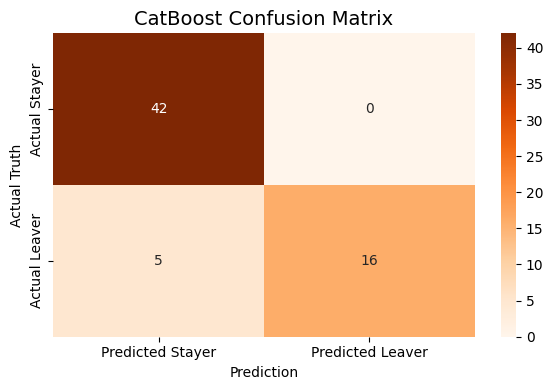


     SHAP EXPLAINABILITY (CATBOOST)



Generating Global Summary Plot...


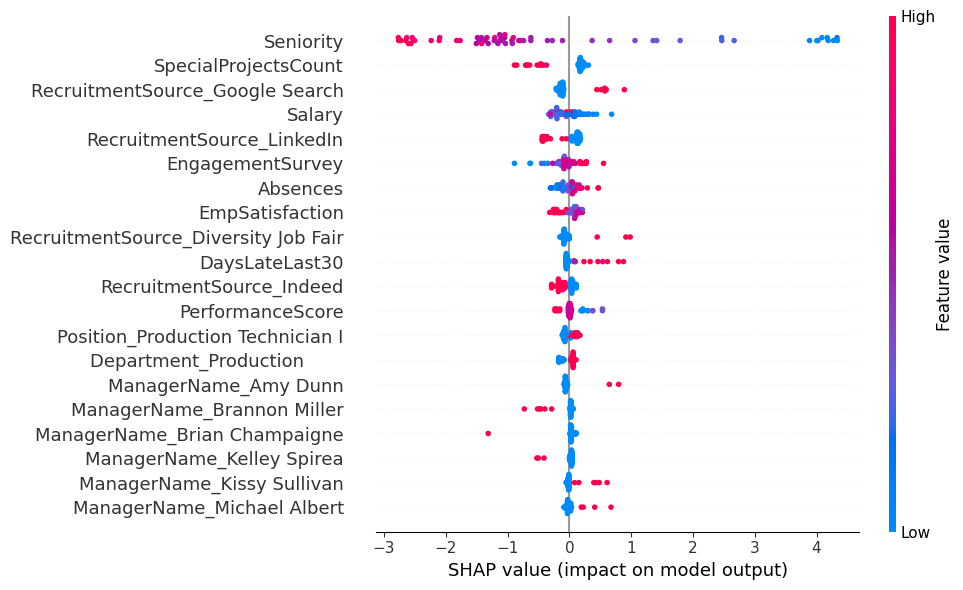


Generating Local Waterfall Plot for Employee #0...


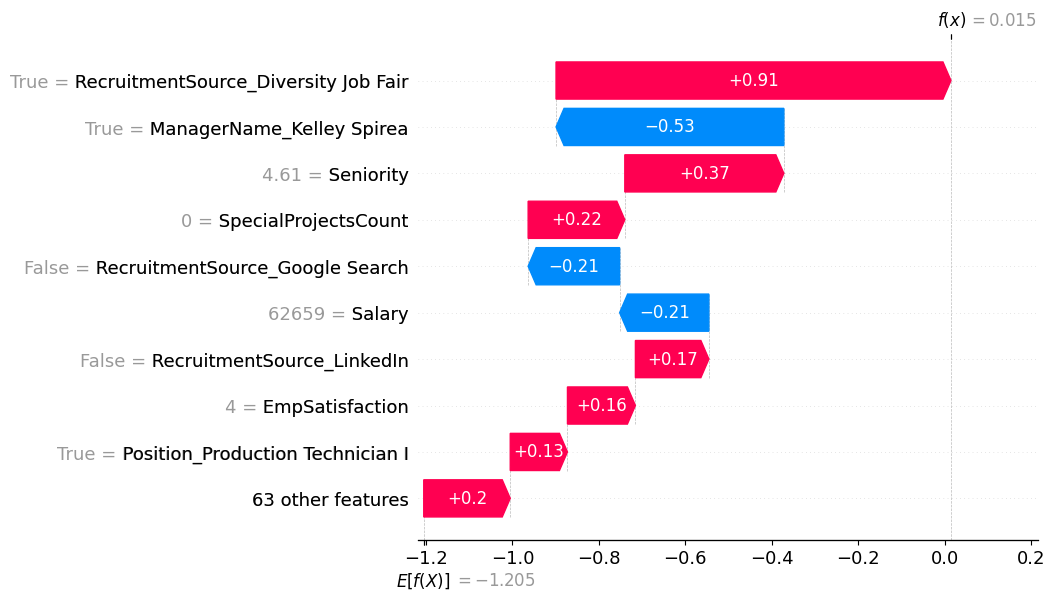

In [134]:
# --- 1. Define Features (X) and Target (y) ---
# Assuming 'df' is your fully cleaned DataFrame
X = df.drop('Termd', axis=1)
y = df['Termd']

# --- 2. Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training dataset size: {X_train.shape[0]} employees")
print(f"Testing dataset size: {X_test.shape[0]} employees")

# --- 3. Initialize and Train CatBoost Model ---
cat_model = CatBoostClassifier(
    iterations=100,           # Number of trees (equivalent to n_estimators)
    learning_rate=0.1,        # Step size
    depth=4,                  # Tree depth (keep low for explainability and avoiding overfitting)
    random_seed=42,
    eval_metric='Logloss',    # Standard binary classification metric
    verbose=False             # Set to False to prevent it from printing 100 lines of training logs
)

# Train the model
print("\nTraining CatBoost model...")
cat_model.fit(X_train, y_train)

# --- 4. Evaluate Performance ---
# Predict exact class (0 or 1)
y_pred = cat_model.predict(X_test)
# Predict probability
y_pred_proba = cat_model.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print("     CATBOOST MODEL PERFORMANCE")
print("="*40)

# Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}  (Overall correctness)")
print(f"Precision: {precision:.4f}  (When it predicts 'Quit', how often is it right?)")
print(f"Recall:    {recall:.4f}  (How many total 'Quitters' did it catch?)")
print(f"F1 Score:  {f1:.4f}  (Balance of Precision and Recall)")
print(f"ROC AUC:   {roc_auc:.4f}  (Ability to distinguish classes)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Visualize the Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Oranges for CatBoost
            xticklabels=['Predicted Stayer', 'Predicted Leaver'],
            yticklabels=['Actual Stayer', 'Actual Leaver'])
plt.title('CatBoost Confusion Matrix', fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('Actual Truth')
plt.tight_layout()
plt.show()

# --- 6. SHAP EXPLAINABILITY FOR CATBOOST ---
print("\n" + "="*40)
print("     SHAP EXPLAINABILITY (CATBOOST)")
print("="*40)

# Initialize JS visualization for SHAP inside Jupyter
shap.initjs()

# Create the SHAP Explainer
# CatBoost has a native wrap for SHAP, but the TreeExplainer works beautifully.
explainer = shap.TreeExplainer(cat_model)

# Calculate SHAP values for the Test set
shap_values = explainer.shap_values(X_test)

# A. GLOBAL EXPLAINABILITY (Summary Plot)
print("\nGenerating Global Summary Plot...")
plt.figure(figsize=(10, 6))
# For CatBoost binary classification, shap_values is usually a single array (unlike LightGBM's list)
shap.summary_plot(shap_values, X_test, plot_size=(10, 6))

# B. LOCAL EXPLAINABILITY (Explaining a Single Employee's Risk)
print("\nGenerating Local Waterfall Plot for Employee #0...")
employee_index = 0

# Extract values for the single employee
single_person_shap = shap_values[employee_index]
expected_val = explainer.expected_value

# Create the Explanations object required by the waterfall plot
explanation_object = shap.Explanation(
    values=single_person_shap, 
    base_values=expected_val, 
    data=X_test.iloc[employee_index].values, 
    feature_names=X_test.columns
)

# Draw the waterfall plot
plt.figure(figsize=(8, 5))
shap.plots.waterfall(explanation_object, max_display=10)


In [135]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_cat = cross_val_score(
    CatBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbose=0          # silences training logs
    ),
    X, y,
    cv=cv,
    scoring='roc_auc'
)

print(f"CatBoost  CV ROC AUC: {scores_cat.mean():.3f} ± {scores_cat.std():.3f}")
print(f"Individual folds: {scores_cat.round(3)}")

# Full comparison
print("\n--- Final Model Comparison ---")
print(f"XGBoost   CV ROC AUC: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"LightGBM  CV ROC AUC: {scores_lgbm.mean():.3f} ± {scores_lgbm.std():.3f}")
print(f"CatBoost  CV ROC AUC: {scores_cat.mean():.3f} ± {scores_cat.std():.3f}")

CatBoost  CV ROC AUC: 0.927 ± 0.024
Individual folds: [0.904 0.893 0.936 0.954 0.947]

--- Final Model Comparison ---
XGBoost   CV ROC AUC: 0.903 ± 0.053
LightGBM  CV ROC AUC: 0.930 ± 0.015
CatBoost  CV ROC AUC: 0.927 ± 0.024


## RandomForestClassifier

Training dataset size: 248 employees
Testing dataset size: 63 employees

Training Random Forest model...

     RANDOM FOREST MODEL PERFORMANCE
Accuracy:  0.9206  (Overall correctness)
Precision: 1.0000  (When it predicts 'Quit', how often is it right?)
Recall:    0.7619  (How many total 'Quitters' did it identify?)
F1 Score:  0.8649  (Balance of Precision and Recall)
ROC AUC:   0.9603  (Ability to distinguish classes)

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        42
           1       1.00      0.76      0.86        21

    accuracy                           0.92        63
   macro avg       0.95      0.88      0.90        63
weighted avg       0.93      0.92      0.92        63



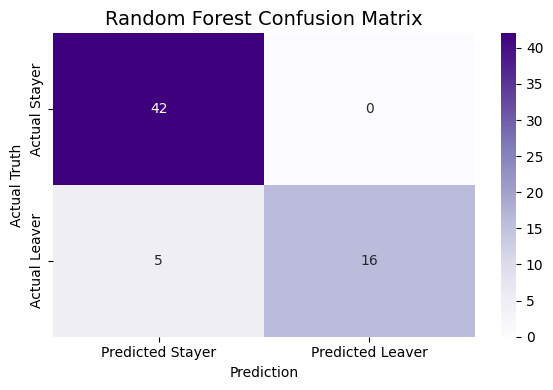

In [136]:
# --- 1. Define Features (X) and Target (y) ---
X = df.drop('Termd', axis=1)
y = df['Termd']

# --- 2. Train / Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training dataset size: {X_train.shape[0]} employees")
print(f"Testing dataset size: {X_test.shape[0]} employees")

# --- 3. Initialize and Train Random Forest Model ---
rf_model = RandomForestClassifier(
    n_estimators=100,       # Number of trees in the forest
    max_depth=5,            # Keep trees somewhat shallow to prevent overfitting
    n_jobs=-1,              # Use all CPU cores for faster training
    random_state=42,
    class_weight='balanced' # Excellent for HR datasets if 'Terminated' is a rare event
)

# Train the model
print("\nTraining Random Forest model...")
rf_model.fit(X_train, y_train)

# --- 4. Evaluate Performance ---
# Predict exact class (0 or 1)
y_pred = rf_model.predict(X_test)
# Predict probability (percentage risk)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("\n" + "="*40)
print("     RANDOM FOREST MODEL PERFORMANCE")
print("="*40)

# Calculate core metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}  (Overall correctness)")
print(f"Precision: {precision:.4f}  (When it predicts 'Quit', how often is it right?)")
print(f"Recall:    {recall:.4f}  (How many total 'Quitters' did it identify?)")
print(f"F1 Score:  {f1:.4f}  (Balance of Precision and Recall)")
print(f"ROC AUC:   {roc_auc:.4f}  (Ability to distinguish classes)")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# --- 5. Visualize the Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', # Purples for Random Forest
            xticklabels=['Predicted Stayer', 'Predicted Leaver'],
            yticklabels=['Actual Stayer', 'Actual Leaver'])
plt.title('Random Forest Confusion Matrix', fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('Actual Truth')
plt.tight_layout()
plt.show()

In [137]:
scores_rf = cross_val_score(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        random_state=42
    ),
    X, y,
    cv=cv,
    scoring='roc_auc'
)

# Full final comparison
print("--- Final Model Comparison ---")
print(f"XGBoost       CV ROC AUC: {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"LightGBM      CV ROC AUC: {scores_lgbm.mean():.3f} ± {scores_lgbm.std():.3f}")
print(f"CatBoost      CV ROC AUC: {scores_cat.mean():.3f} ± {scores_cat.std():.3f}")
print(f"Random Forest CV ROC AUC: {scores_rf.mean():.3f} ± {scores_rf.std():.3f}")

--- Final Model Comparison ---
XGBoost       CV ROC AUC: 0.903 ± 0.053
LightGBM      CV ROC AUC: 0.930 ± 0.015
CatBoost      CV ROC AUC: 0.927 ± 0.024
Random Forest CV ROC AUC: 0.887 ± 0.051


## Plot the result for better visualization and choose the best model

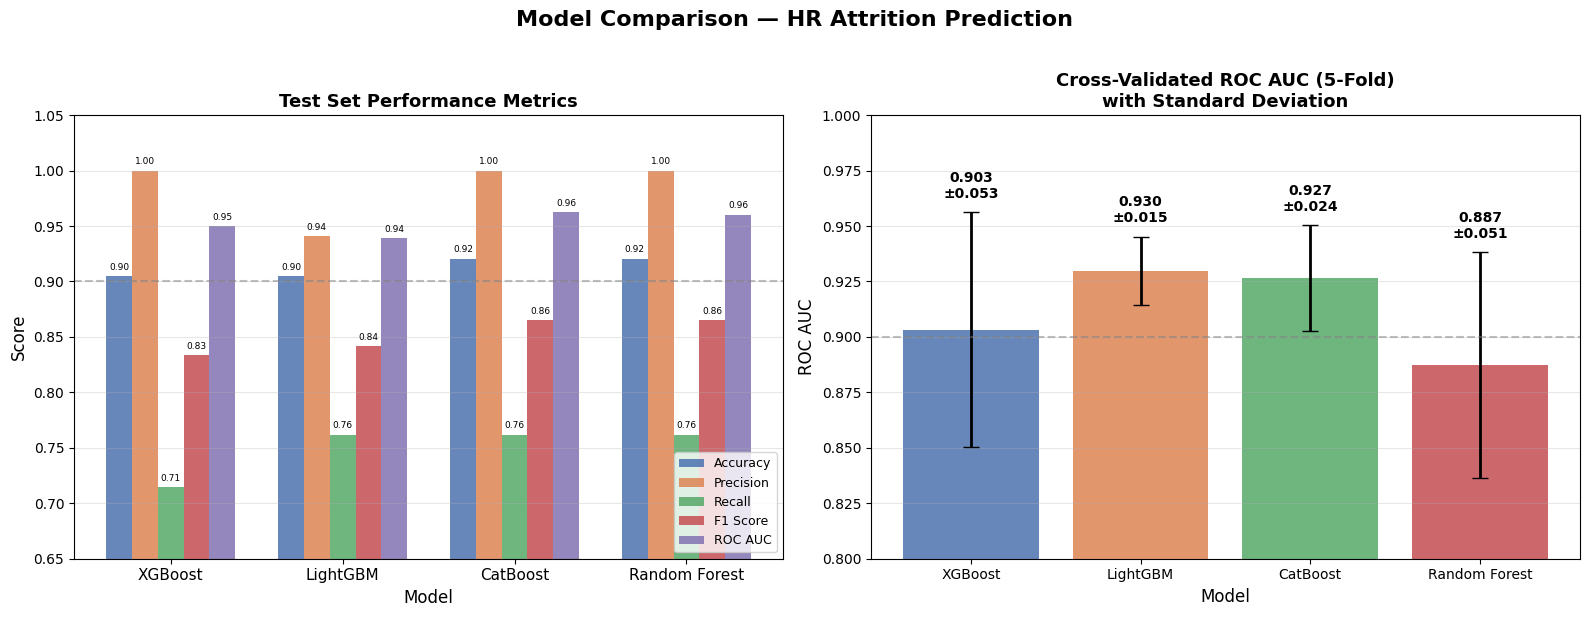


         BEST MODEL SELECTION

Model             CV AUC     ±Std       F1      Score
--------------------------------------------------
XGBoost            0.903    0.053    0.833      0.850
LightGBM           0.930    0.015    0.842      0.914 ✅
CatBoost           0.927    0.024    0.865      0.903
Random Forest      0.887    0.051    0.865      0.836

🏆 Best model: LightGBM
   CV ROC AUC : 0.930 ± 0.015
   F1 Score   : 0.842
   ROC AUC    : 0.939


In [138]:
# --- 1. Collect all results ---
models = ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest']

# Test set metrics
accuracy  = [0.9048, 0.9048, 0.9206, 0.9206]
precision = [1.0000, 0.9412, 1.0000, 1.0000]
recall    = [0.7143, 0.7619, 0.7619, 0.7619]
f1        = [0.8333, 0.8421, 0.8649, 0.8649]
roc_auc   = [0.9501, 0.9388, 0.9626, 0.9603]

# Cross-validation results
cv_means  = [xgb_scores.mean(), scores_lgbm.mean(), scores_cat.mean(), scores_rf.mean()]
cv_stds   = [xgb_scores.std(),  scores_lgbm.std(),  scores_cat.std(),  scores_rf.std()]

# --- 2. Plot test set metrics comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — HR Attrition Prediction', fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Grouped bar chart of all metrics ---
x = np.arange(len(models))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

ax1 = axes[0]
bars1 = ax1.bar(x - 2*width, accuracy,  width, label='Accuracy',  color=colors[0], alpha=0.85)
bars2 = ax1.bar(x - width,   precision, width, label='Precision', color=colors[1], alpha=0.85)
bars3 = ax1.bar(x,           recall,    width, label='Recall',    color=colors[2], alpha=0.85)
bars4 = ax1.bar(x + width,   f1,        width, label='F1 Score',  color=colors[3], alpha=0.85)
bars5 = ax1.bar(x + 2*width, roc_auc,   width, label='ROC AUC',   color=colors[4], alpha=0.85)

ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Test Set Performance Metrics', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)
ax1.set_ylim(0.65, 1.05)
ax1.legend(loc='lower right', fontsize=9)
ax1.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 baseline')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [bars1, bars2, bars3, bars4, bars5]:
    for bar in bars:
        ax1.annotate(f'{bar.get_height():.2f}',
                     xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=6.5)

# --- Plot 2: CV ROC AUC with error bars ---
ax2 = axes[1]
bar_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax2.bar(models, cv_means, color=bar_colors, alpha=0.85,
               yerr=cv_stds, capsize=6, error_kw={'linewidth': 2})

ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('ROC AUC', fontsize=12)
ax2.set_title('Cross-Validated ROC AUC (5-Fold)\nwith Standard Deviation', fontsize=13, fontweight='bold')
ax2.set_ylim(0.80, 1.00)
ax2.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005,
             f'{mean:.3f}\n±{std:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Automatically select the best model ---
print("\n" + "="*50)
print("         BEST MODEL SELECTION")
print("="*50)

results = {
    'XGBoost':       {'cv_mean': cv_means[0], 'cv_std': cv_stds[0], 'f1': f1[0], 'roc_auc': roc_auc[0]},
    'LightGBM':      {'cv_mean': cv_means[1], 'cv_std': cv_stds[1], 'f1': f1[1], 'roc_auc': roc_auc[1]},
    'CatBoost':      {'cv_mean': cv_means[2], 'cv_std': cv_stds[2], 'f1': f1[2], 'roc_auc': roc_auc[2]},
    'Random Forest': {'cv_mean': cv_means[3], 'cv_std': cv_stds[3], 'f1': f1[3], 'roc_auc': roc_auc[3]},
}

# Score = CV mean - CV std penalty (rewards both performance AND stability)
scoring = {name: v['cv_mean'] - v['cv_std'] for name, v in results.items()}
best_model = max(scoring, key=scoring.get)

print(f"\n{'Model':<15} {'CV AUC':>8} {'±Std':>8} {'F1':>8} {'Score':>10}")
print("-"*50)
for name, v in results.items():
    score = scoring[name]
    marker = " ✅" if name == best_model else ""
    print(f"{name:<15} {v['cv_mean']:>8.3f} {v['cv_std']:>8.3f} {v['f1']:>8.3f} {score:>10.3f}{marker}")

print(f"\n🏆 Best model: {best_model}")
print(f"   CV ROC AUC : {results[best_model]['cv_mean']:.3f} ± {results[best_model]['cv_std']:.3f}")
print(f"   F1 Score   : {results[best_model]['f1']:.3f}")
print(f"   ROC AUC    : {results[best_model]['roc_auc']:.3f}")

We now know we want to use LightGBM and we will use SHAP to explain it.